In [1]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import os
os.environ['ESMFMKFILE'] = 'C:/Users/eving/AppData/Local/miniconda3/envs/evalprecextremes/Library/lib/esmf.mk'
import xesmf as xe
import numpy as np
np.float_ = np.float64
import matplotlib.colors as mcolors
from clisops.core import subset
from metpy.plots import ctables
import matplotlib.ticker as ticker
import cmaps
import geopandas as gpd
import seaborn as sns
import rioxarray
from math import nan
from scipy import stats
import statsmodels.api as sm
import cartopy
import matplotlib.colors as colors

In [2]:
# Original Projection
projorig_name  = "PlateCarree"
projorig_dict  = dict()
projorig       = ccrs.__dict__[projorig_name].__call__(**projorig_dict)

# Graphic projection
projplot       = "LambertConformal"
projplot_dict  = dict(central_longitude=10.5, central_latitude=49.5, standard_parallels=(33,45))
projplot       = ccrs.__dict__[projplot].__call__(**projplot_dict)

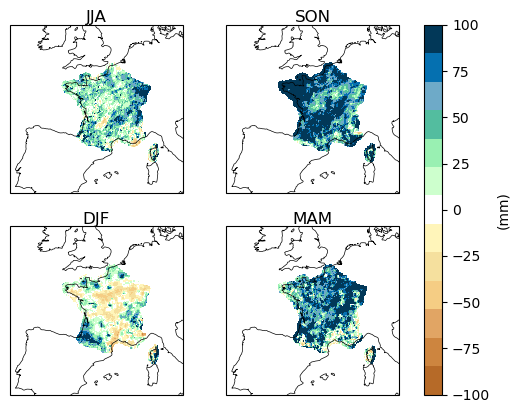

In [17]:
fig, axes = plt.subplots(nrows=2,ncols=2,subplot_kw={'projection': projplot})

seasons = ["JJA","SON","DJF","MAM"]

folder_obs = 'D:/EUROCORDEX_extremes/DATA/OBS/'

folder_RL20 = "D:/EUROCORDEX_extremes/20yrRL/"

spatial_scale = "S1"
temporal_scale = "3hr"

file_obs = f"OBS_EURADCLIM_011EUi_2013-2022_JJA_max_scale_{spatial_scale}.nc"

# choose a season
for ax, season in zip(axes.flat, seasons):
    # load mask
    mask = np.load(f'D:/EUROCORDEX_extremes/DATA/OBS/mask_eurad_{season}_era_{spatial_scale}.npy')
    
    # RL20 from obs
    temporal_scale = "24hr"
    file_RL20_obs = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_EURADCLIM_011EUi_2013-2022.csv"
    RL20_obs = np.loadtxt(fname=folder_RL20+file_RL20_obs, delimiter=',')
    RL20_obs[RL20_obs<0] = np.nan
    #RL20_obs = np.where(mask, np.nan, RL20_obs) # Set values outside the range to NaN
    
    # RL20 from sim
    temporal_scale = "24hr"
    file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_COMEPHORE_011EUi_1997-2022.csv"
    #file_RL20_sim = f"matrix_10yrRL_{temporal_scale}_{spatial_scale}_{season}_OBS_COMEPHORE_011EUi_1997-2022.csv"
    RL20_sim = np.loadtxt(fname=folder_RL20+file_RL20_sim, delimiter=',')
    RL20_sim[RL20_sim<0] = np.nan
    #RL20_sim = np.where(mask, np.nan, RL20_sim) # Set values outside the range to NaN

    diff = (RL20_obs / RL20_sim - 1)*100


    dsObs = xr.load_dataset(folder_obs+file_obs, engine="netcdf4", decode_timedelta=False)

    plot = ax.pcolormesh(dsObs.lon, dsObs.lat, diff, cmap=cmaps.precip_diff_12lev, vmin=-100, vmax=100,
                        transform=projorig, zorder=1)

    ax.set_title(season, fontsize=12, pad=1.0)
    ax.set_extent((-10, 13, 38, 54))  # France zoom
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)        # Draw coastlines

plt.colorbar(plot, ax=axes, orientation='vertical', label='(mm)')
